In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [ ]:
# Standard library imports
import random
import warnings
from pathlib import Path

# Data handling and visualization imports
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Deep learning framework imports - PyTorch and Keras
import torch
from torch.utils.data import Dataset, DataLoader
import keras
from keras import layers

# Cats vs dogs classification

## Introduction

This project addresses a classic binary image classification problem: distinguishing between images of cats and dogs. The goal of this initial phase is to build a simple, working end-to-end pipeline - from raw images to a trained classifier with basic evaluation.

The project starts intentionally simple: a small convolutional neural network trained from scratch on a subset of the data, to establish a working baseline. Once this baseline is validated end-to-end, the project will be extended in later iterations.

## 1. Environment Setup

Before working with the data, we configure the Keras backend to use PyTorch, set random seeds for reproducibility across all libraries, and select the available compute device (GPU if available, otherwise CPU).

In [ ]:
warnings.filterwarnings("ignore") # Ignore warnings for cleaner output

In [ ]:
SEED = 42 # Master seed for all random operations

In [ ]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED) # PyTorch's random module for CPU
keras.utils.set_random_seed(SEED) # Keras's global random seed

In [ ]:
# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 2. Dataset Overview

We use the official Microsoft "Kaggle Cats and Dogs" dataset, containing approximately 25,000 images split evenly between two classes: **Cat** and **Dog**. The dataset is downloaded directly via `keras.utils.get_file`, which handles both the download and extraction of the archive.

In [ ]:
# Download the official Microsoft Cats vs Dogs dataset
dataset_url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

archive_path = keras.utils.get_file(
    fname="kagglecatsanddogs_5340.zip",
    origin=dataset_url,
    extract=True
)

# Define the base directory where images are stored
data_dir = Path(archive_path) / "PetImages"

In [ ]:
print(f"Dataset extracted to: {data_dir}")
print(f"Cat images: {len(list((data_dir / 'Cat').glob('*.jpg')))}")
print(f"Dog images: {len(list((data_dir / 'Dog').glob('*.jpg')))}")

Dataset extracted to: /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages
Cat images: 12500
Dog images: 12500


### Data Cleaning

The raw dataset contains a small number of corrupted image files that are not valid JFIF-encoded JPEGs. These files can cause errors later during training, so we scan every image, verify its file signature, and remove any file that fails the check.

In [ ]:
# The dataset contains a few corrupted JFIF images - filter them out before use
num_skipped = 0
all_paths = []

for category in ("Cat", "Dog"):
    folder_path = data_dir / category
    folder_files = list(folder_path.glob("*.jpg"))
    all_paths.extend(folder_files)

    for i, fname in enumerate(folder_files):
        try:
            with open(fname, "rb") as f:
                is_jfif = b"JFIF" in f.peek(10)
            if not is_jfif:
                num_skipped += 1
                os.remove(fname)
        except Exception:
            num_skipped += 1
            os.remove(fname)

        if (i + 1) % 2000 == 0:
            print(f"{category}: checked {i + 1}/{len(folder_files)} images")

print(f"Deleted {num_skipped} corrupted images")

Cat: checked 2000/12500 images
Cat: checked 4000/12500 images
Cat: checked 6000/12500 images
Cat: checked 8000/12500 images
Cat: checked 10000/12500 images
Cat: checked 12000/12500 images
Dog: checked 2000/12500 images
Dog: checked 4000/12500 images
Dog: checked 6000/12500 images
Dog: checked 8000/12500 images
Dog: checked 10000/12500 images
Dog: checked 12000/12500 images
Deleted 1590 corrupted images


## 3. Exploratory Data Analysis (EDA)

With the dataset cleaned, we take a first look at the data: counting the total number of usable images and visually inspecting a random sample to confirm the images loaded correctly and look as expected.

In [ ]:
all_image_paths = (
    list((data_dir / 'Cat').glob('*.jpg')) +
    list((data_dir / 'Dog').glob('*.jpg'))
)

print(f"Total images found: {len(all_image_paths)}")

Total images found: 23410


Selected random image: /root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages/Dog/4504.jpg


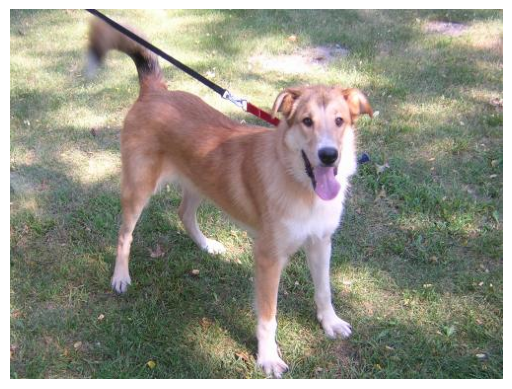

In [ ]:
random_image_path = random.choice(all_image_paths)
print(f"Selected random image: {random_image_path}")

image = Image.open(random_image_path)
plt.imshow(image)
plt.axis('off')
plt.show()

### 3.1 Class Distribution

We check how many images belong to each class after the data cleaning step, to confirm the dataset remains balanced between cats and dogs.

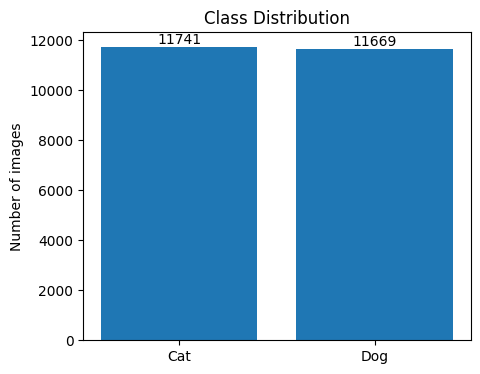

In [ ]:
cat_count = len(list((data_dir / "Cat").glob("*.jpg")))
dog_count = len(list((data_dir / "Dog").glob("*.jpg")))

plt.figure(figsize=(5, 4))
bars = plt.bar(["Cat", "Dog"], [cat_count, dog_count])
plt.title("Class Distribution")
plt.ylabel("Number of images")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(height), ha="center", va="bottom")

plt.show()

The dataset remains well balanced after cleaning: 11,741 cat images and 11,669 dog images, a difference of less than 1%. This means we can train and evaluate the model using plain accuracy as a metric, without needing class weighting or resampling techniques to handle imbalance.

### 3.2 Sample Images from Each Class

To get a better sense of the data, we display a grid of random sample images from both classes.

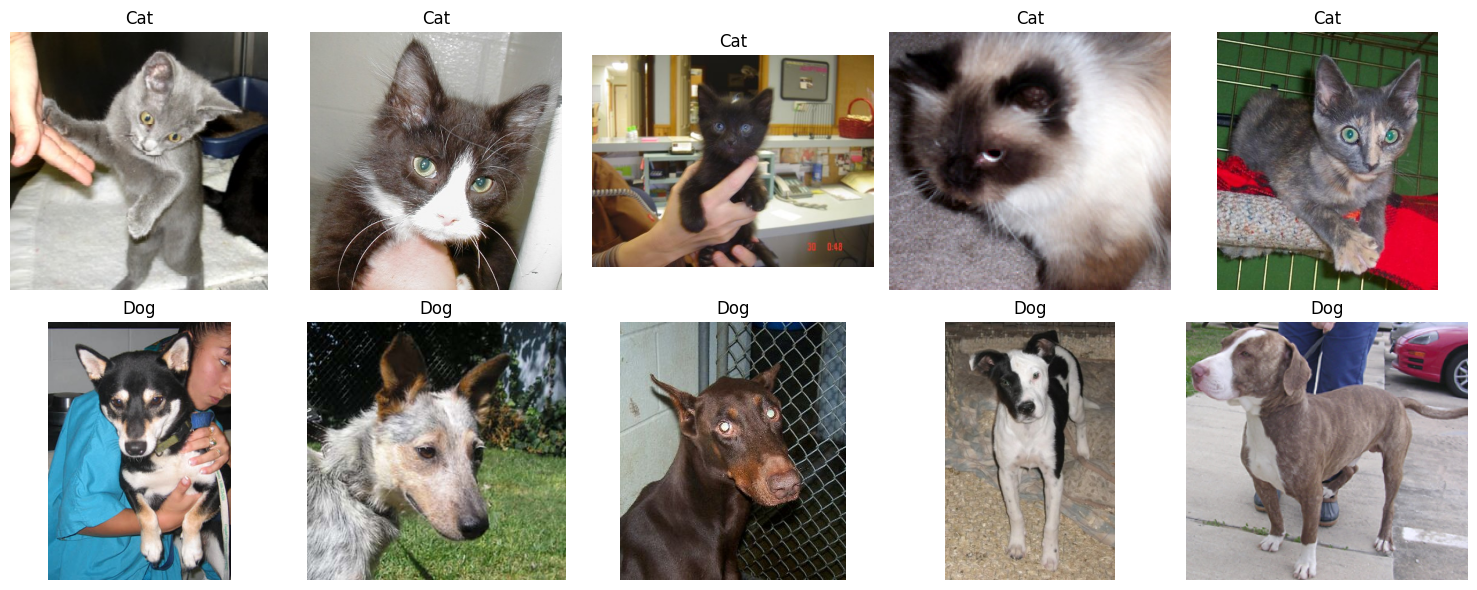

In [ ]:
cat_paths = list((data_dir / "Cat").glob("*.jpg"))
dog_paths = list((data_dir / "Dog").glob("*.jpg"))

sample_cats = random.sample(cat_paths, 5)
sample_dogs = random.sample(dog_paths, 5)
sample_images = sample_cats + sample_dogs
sample_labels = ["Cat"] * 5 + ["Dog"] * 5

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, path, label in zip(axes.flatten(), sample_images, sample_labels):
    image = Image.open(path)
    ax.imshow(image)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

The sample images confirm that this is a real-world, unfiltered dataset: photos vary widely in pose, background, lighting, and framing (close-up portraits, full-body shots, indoor and outdoor scenes). This diversity is useful for training a model that generalizes well, but it also means the model cannot rely on consistent backgrounds or camera angles to make predictions.

### 3.3 Image Dimensions Analysis

Real-world images in this dataset vary in size. Before deciding on a fixed input size for the model, we sample a subset of images and inspect the distribution of their widths and heights.

Width  - min: 58, max: 500, mean: 412.9
Height - min: 50, max: 500, mean: 366.7


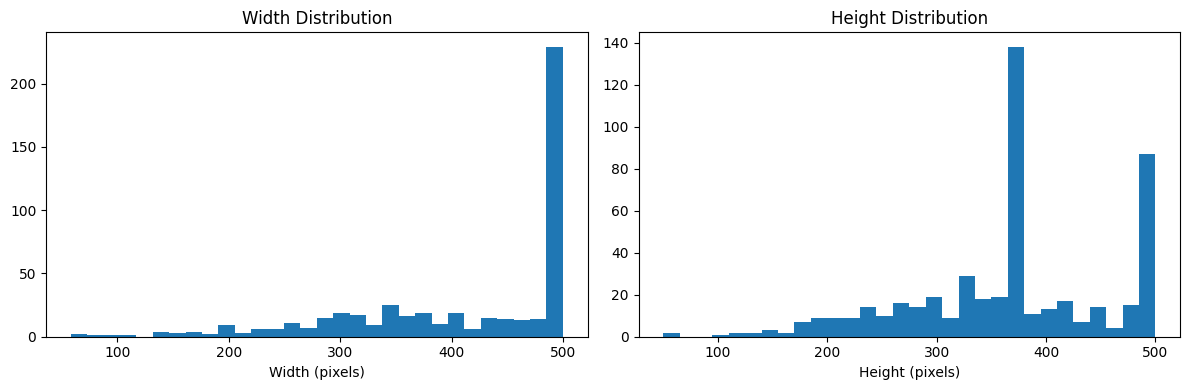

In [ ]:
sample_size = 500
sampled_paths = random.sample(all_image_paths, sample_size)

widths = []
heights = []

for path in sampled_paths:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

widths = np.array(widths)
heights = np.array(heights)

print(f"Width  - min: {widths.min()}, max: {widths.max()}, mean: {widths.mean():.1f}")
print(f"Height - min: {heights.min()}, max: {heights.max()}, mean: {heights.mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30)
axes[0].set_title("Width Distribution")
axes[0].set_xlabel("Width (pixels)")

axes[1].hist(heights, bins=30)
axes[1].set_title("Height Distribution")
axes[1].set_xlabel("Height (pixels)")

plt.tight_layout()
plt.show()

Image dimensions vary substantially: widths range from 58 to 500 pixels (mean 412.7) and heights from 50 to 500 pixels (mean 366.5). Both distributions are skewed toward the upper bound, with a large spike of images at exactly 500 pixels. This confirms that all images must be resized to a fixed input shape before being fed into the model, since a CNN requires consistent input dimensions.

### 3.4 Aspect Ratio Distribution

We also check the aspect ratio (width divided by height) of the sampled images, to see how far most images deviate from a square shape.

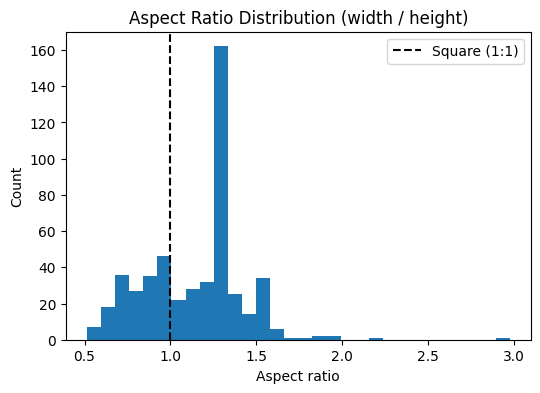

In [ ]:
aspect_ratios = widths / heights

plt.figure(figsize=(6, 4))
plt.hist(aspect_ratios, bins=30)
plt.title("Aspect Ratio Distribution (width / height)")
plt.xlabel("Aspect ratio")
plt.ylabel("Count")
plt.axvline(1.0, color="black", linestyle="--", label="Square (1:1)")
plt.legend()
plt.show()

Most images have an aspect ratio between 0.5 and 2.0, with a clear peak around 1.3 to 1.4 (slightly wider than tall). Relatively few images are perfectly square (ratio of 1.0). Since the spread is moderate rather than extreme, a direct resize to a fixed square shape is a reasonable choice for this project, without requiring more complex padding or cropping strategies to preserve aspect ratio.

## 4. Data Preprocessing

Before training a model, the raw images need to be converted into a consistent format. Based on the EDA results, image sizes vary significantly, so all images will be resized to a fixed shape. Pixel values will be normalized to the [0, 1] range, and the data will be organized into a PyTorch `Dataset` and `DataLoader` pipeline for efficient batching during training.

### 4.1 Building the Sample List

We combine the cat and dog image paths into a single list of (path, label) pairs, using 0 for Cat and 1 for Dog, and shuffle the list so that both classes are mixed before splitting.

In [ ]:
IMAGE_SIZE = 128 # chosen based on the EDA size distribution

In [ ]:
cat_paths = list((data_dir / "Cat").glob("*.jpg"))
dog_paths = list((data_dir / "Dog").glob("*.jpg"))

all_samples = [(p, 0) for p in cat_paths] + [(p, 1) for p in dog_paths]
random.shuffle(all_samples)

print(f"Total samples: {len(all_samples)}")
print(f"Example: {all_samples[0]}")

Total samples: 23410
Example: (PosixPath('/root/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages/Dog/1206.jpg'), 1)


### 4.2 Train / Validation / Test Split

The shuffled samples are split into training (70%), validation (15%), and test (15%) sets using simple slicing, since the list is already randomly shuffled.

In [ ]:
train_ratio = 0.7
val_ratio = 0.15
# remaining 0.15 goes to the test set

n_total = len(all_samples)
n_train = int(n_total * train_ratio)
n_val = int(n_total * val_ratio)

train_samples = all_samples[:n_train]
val_samples = all_samples[n_train:n_train + n_val]
test_samples = all_samples[n_train + n_val:]

print(f"Train samples: {len(train_samples)}")
print(f"Validation samples: {len(val_samples)}")
print(f"Test samples: {len(test_samples)}")

Train samples: 16387
Validation samples: 3511
Test samples: 3512


### 4.3 PyTorch Dataset Class

We define a custom PyTorch `Dataset` that loads an image from disk, converts it to RGB (a small number of images are grayscale), resizes it to a fixed shape, scales pixel values to the [0, 1] range, and converts it to a tensor in the (channels, height, width) format expected by PyTorch.

In [ ]:
class CatsDogsDataset(Dataset):
    def __init__(self, samples, image_size=IMAGE_SIZE):
        self.samples = samples
        self.image_size = image_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        image = Image.open(path).convert("RGB")
        image = image.resize((self.image_size, self.image_size))

        image_array = np.array(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image_array).permute(2, 0, 1)

        return image_tensor, torch.tensor(label, dtype=torch.long)

### 4.4 Creating DataLoaders

The three datasets (train, validation, test) are wrapped in PyTorch `DataLoader` objects, which handle batching. The training loader shuffles the data on every epoch, while validation and test loaders keep a fixed order.

In [ ]:
BATCH_SIZE = 32

In [ ]:
train_dataset = CatsDogsDataset(train_samples)
val_dataset = CatsDogsDataset(val_samples)
test_dataset = CatsDogsDataset(test_samples)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 513
Number of validation batches: 110
Number of test batches: 110


### 4.5 Sanity Check

Before moving on to the model, we verify that a batch from the training loader has the expected shape: batch size, 3 color channels, and the fixed image dimensions.

In [ ]:
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")
print(f"Batch label shape: {labels.shape}")

Batch image shape: torch.Size([32, 3, 128, 128])
Batch label shape: torch.Size([32])




We build a simple convolutional neural network from scratch using Keras, running on the PyTorch backend. The architecture uses three convolutional blocks with increasing filter counts, followed by global average pooling and a dense classification head. This serves as our baseline model before any transfer learning or further tuning is introduced.

## 5. Model Architecture

### 5.1 Data Format Configuration

Our PyTorch `Dataset` produces image tensors in (channels, height, width) format, following PyTorch convention. By default, Keras expects images in (height, width, channels) format instead. To avoid permuting every batch, we configure Keras to use the channels-first format globally, matching our existing data pipeline.

In [ ]:
keras.config.set_image_data_format("channels_first")

### 5.2 Defining the CNN

The model consists of three convolutional blocks (16, 32, and 64 filters), each followed by max pooling to progressively reduce the spatial dimensions. Instead of flattening the final feature maps, we use global average pooling, which reduces the number of parameters and helps limit overfitting on this basic baseline. A dropout layer is added before the final output for additional regularization. Since this is a binary classification problem (cat vs dog), the output layer has a single unit with a sigmoid activation.

In [ ]:
def build_cnn(image_size=IMAGE_SIZE):
    model = keras.Sequential([
        keras.Input(shape=(3, image_size, image_size)),

        layers.Conv2D(16, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(32, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(64, kernel_size=3, activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])

    return model

In [ ]:
model = build_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 128, 128)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 64, 64)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 32, 32)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,809 (108.63 KB)

 Trainable params: 27,809 (108.63 KB)

 Non-trainable params: 0 (0.00 B)

### 5.3 Sanity Check

Before setting up training, we pass a single batch through the untrained model to confirm the output shape matches expectations: one probability value per image in the batch.

In [ ]:
sample_images, sample_labels = next(iter(train_loader))
sample_output = model(sample_images)

In [ ]:
print(f"Input batch shape: {sample_images.shape}")
print(f"Output shape: {sample_output.shape}")
print(f"Sample predictions (untrained model): {sample_output[:5]}")

Input batch shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 1])
Sample predictions (untrained model): tensor([[0.5050],
        [0.5048],
        [0.5062],
        [0.5042],
        [0.5052]], device='cuda:0', grad_fn=<SliceBackward0>)


The model summary confirms a lightweight baseline with 27,809 trainable parameters, small enough to train quickly even on limited compute. The sanity check confirms the pipeline works end-to-end: a batch of shape (32, 3, 128, 128) produces an output of shape (32, 1), with predictions close to 0.5 as expected from an untrained model with sigmoid output (since the model has not yet learned to distinguish the classes).

## 6. Training Setup

Before training, the model is compiled with a loss function, optimizer, and evaluation metric. Since this is binary classification with a sigmoid output, we use binary crossentropy as the loss function and Adam as the optimizer. We also add early stopping to prevent unnecessary training once the validation performance stops improving.

In [ ]:
model.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
)

### 6.1 Training the Model

The model is trained for a fixed maximum number of epochs, using the training and validation `DataLoader` objects created earlier. Early stopping will halt training automatically if the validation loss stops improving.

In [ ]:
EPOCHS = 15

In [ ]:
history = model.fit(
    train_loader,
    validation_data=val_loader,
    epochs=EPOCHS,
    callbacks=[early_stopping],
)

Epoch 1/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 83s 158ms/step - accuracy: 0.5572 - loss: 0.6768 - val_accuracy: 0.6149 - val_loss: 0.6533
Epoch 2/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 80s 156ms/step - accuracy: 0.6151 - loss: 0.6490 - val_accuracy: 0.5597 - val_loss: 0.7044
Epoch 3/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 80s 156ms/step - accuracy: 0.6455 - loss: 0.6277 - val_accuracy: 0.6616 - val_loss: 0.6089
Epoch 4/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 79s 154ms/step - accuracy: 0.6757 - loss: 0.6030 - val_accuracy: 0.6858 - val_loss: 0.5822
Epoch 5/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 79s 154ms/step - accuracy: 0.7004 - loss: 0.5790 - val_accuracy: 0.7206 - val_loss: 0.5508
Epoch 6/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 80s 156ms/step - accuracy: 0.7236 - loss: 0.5540 - val_accuracy: 0.7024 - val_loss: 0.5660
Epoch 7/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 81s 158ms/step - accuracy: 0.7355 - loss: 0.5387 - val_accuracy: 0.7206 - val_loss: 0.5445
Epoch 8/15
513/513 ━━━━━━━━━━━━━━━━━━━━ 79s 155ms/step - accuracy: 0.7394 - loss: 0

The baseline model reached a validation accuracy of approximately 80.12% after 15 epochs, with training accuracy at 79.97%. The close gap between training and validation metrics suggests the model is not significantly overfitting at this point. Since early stopping did not trigger and the validation loss was still decreasing at epoch 15, the model may benefit from additional training epochs in a later iteration.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

MODEL_DIR = "/content/drive/MyDrive/cats-vs-dogs-project"
os.makedirs(MODEL_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model_path = os.path.join(MODEL_DIR, "baseline_cnn.keras")
model.save(model_path)
print(f"Model saved to: {model_path}")

Model saved to: /content/drive/MyDrive/cats-vs-dogs-project/baseline_cnn.keras


In [ ]:
model_path = os.path.join(MODEL_DIR, "baseline_cnn.keras")

if os.path.exists(model_path):
    model = keras.models.load_model(model_path)
    print("Loaded existing trained model - skipping training.")
else:
    print("No saved model found - will train from scratch.")

Loaded existing trained model - skipping training.


### 6.2 Training and Loss Curves

To better understand the training process, we plot the training and validation accuracy and loss over the epochs. This helps visually confirm whether the model is still improving, has plateaued, or is starting to overfit.

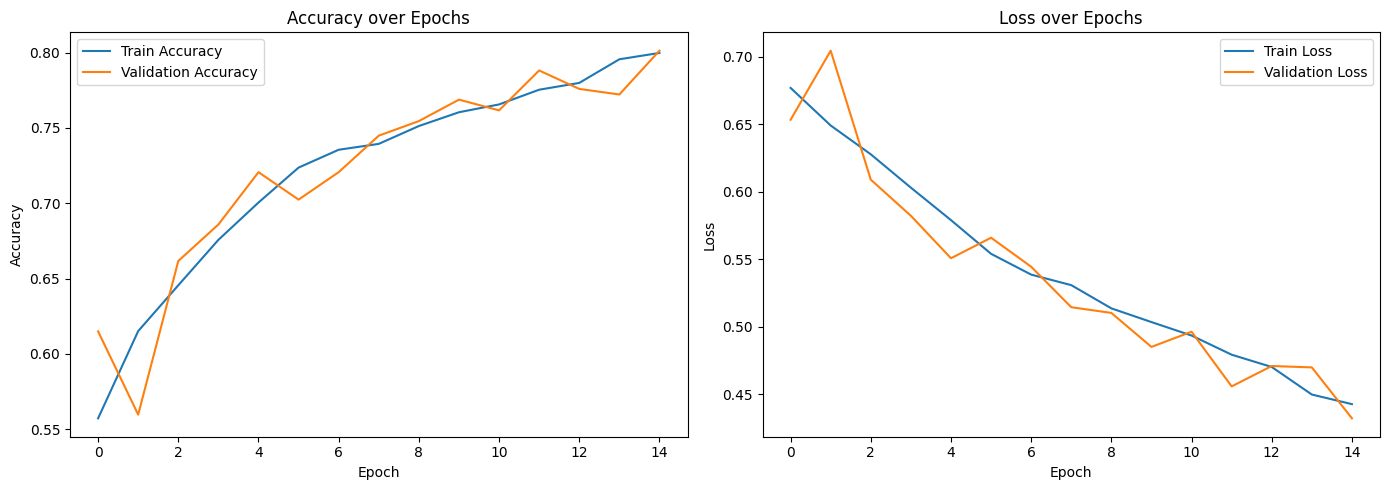

In [ ]:
history_dict = history.history

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_dict["accuracy"], label="Train Accuracy")
axes[0].plot(history_dict["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_dict["loss"], label="Train Loss")
axes[1].plot(history_dict["val_loss"], label="Validation Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Both accuracy curves rise together throughout training, though validation accuracy is noticeably noisier than training accuracy, including a temporary dip around epochs 11-13 before recovering sharply at epoch 14 to finish slightly above the training curve. The validation loss follows a similar pattern, with a brief upward bump around epochs 12-13 before dropping to its lowest point at epoch 14. Despite this noise, there is no sustained divergence between training and validation performance, indicating the model is not overfitting. Both curves are still trending favorably by epoch 14 (the 15th epoch), suggesting additional training epochs could yield further improvement.

## 7. Evaluation

We evaluate the trained model on the held-out test set, which was not used during training or for early stopping decisions. Predictions are compared against the true labels to compute a confusion matrix and standard classification metrics, all implemented manually with NumPy.

### 7.1 Generating Predictions on the Test Set

We run the trained model on every batch of the test set, collecting the predicted class (0 for Cat, 1 for Dog) alongside the true labels. Since the model outputs a sigmoid probability, predictions above 0.5 are classified as Dog, and predictions below 0.5 as Cat.

In [ ]:
model.eval()

all_predictions = []
all_true_labels = []
all_paths = []  # keep paths aligned with predictions, no reliance on external order

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = (outputs.squeeze() > 0.5).int()

        all_predictions.extend(predicted.cpu().numpy().tolist())
        all_true_labels.extend(labels.cpu().numpy().tolist())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

# Paths come directly from the dataset, in the same fixed order (shuffle=False)
all_paths = [path for path, _ in test_samples]

assert len(all_paths) == len(all_predictions), "Mismatch between paths and predictions length"

print(f"Total test predictions: {len(all_predictions)}")

Total test predictions: 3512


### 7.2 Confusion Matrix

The confusion matrix shows how many predictions fall into each combination of true and predicted class: true positives, true negatives, false positives, and false negatives.

In [ ]:
def compute_confusion_matrix(y_true, y_pred, num_classes=2):
    matrix = np.zeros((num_classes, num_classes), dtype=int)

    for true_label, pred_label in zip(y_true, y_pred):
        matrix[true_label, pred_label] += 1

    return matrix

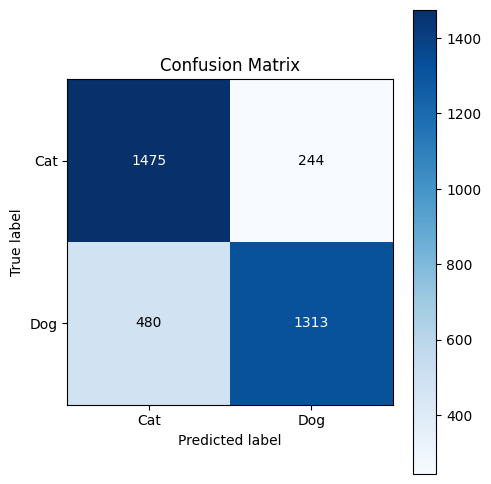

In [ ]:
conf_matrix = compute_confusion_matrix(all_true_labels, all_predictions)
class_names = ["Cat", "Dog"]

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(conf_matrix, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(conf_matrix[i, j]), ha="center", va="center",
                 color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")

plt.colorbar(im)
plt.tight_layout()
plt.show()

Out of 1,719 cat images, 1,475 were correctly classified while 244 were misclassified as dogs. Out of 1,793 dog images, 1,313 were correctly classified while 480 were misclassified as cats. The errors are relatively balanced between the two classes, with slightly more dog images being misclassified as cats than the reverse, suggesting the model does not have a strong bias toward either class.

### 7.3 Classification Metrics

From the confusion matrix, we compute overall accuracy, along with per-class precision, recall, and F1-score. Precision measures how many predicted positives were correct, recall measures how many actual positives were found, and F1-score balances the two.

In [ ]:
def compute_metrics(conf_matrix, class_names):
    accuracy = np.trace(conf_matrix) / conf_matrix.sum()
    print(f"Overall Accuracy: {accuracy:.4f}\n")

    for i, name in enumerate(class_names):
        tp = conf_matrix[i, i]
        fp = conf_matrix[:, i].sum() - tp
        fn = conf_matrix[i, :].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        print(f"{name}: precision={precision:.4f}, recall={recall:.4f}, f1={f1:.4f}")

In [ ]:
compute_metrics(conf_matrix, class_names)

Overall Accuracy: 0.7938

Cat: precision=0.7545, recall=0.8581, f1=0.8029
Dog: precision=0.8433, recall=0.7323, f1=0.7839


The model achieves an overall test accuracy of 79.38%, closely matching the validation accuracy observed during training, which confirms the model generalizes consistently to unseen data. Precision and recall are fairly balanced for both classes: cats have higher recall (85.81%) but lower precision (75.45%) than dogs (73.23% recall, 84.33% precision), meaning the model is somewhat more likely to mislabel a dog as a cat than the other way around. The F1-scores for both classes are 0.8029 for Cat and 0.7839 for Dog, indicating balanced performance across classes rather than one class being favored at the expense of the other.

## 8. Error Analysis

Beyond aggregate metrics, it is useful to visually inspect specific misclassified images. This can reveal patterns in the model's mistakes, such as difficult poses, unusual lighting, occlusion, or ambiguous images that even a human might find hard to classify correctly.

### 8.1 Identifying Misclassified Images

We compare the test set predictions against the true labels to find which images were misclassified, and split them into two groups: cats misclassified as dogs, and dogs misclassified as cats.

In [ ]:
misclassified_indices = np.where(all_predictions != all_true_labels)[0]
print(f"Total misclassified images: {len(misclassified_indices)} out of {len(all_true_labels)}")

false_positive_idx = [i for i in misclassified_indices if all_true_labels[i] == 0]  # Cat predicted as Dog
false_negative_idx = [i for i in misclassified_indices if all_true_labels[i] == 1]  # Dog predicted as Cat

print(f"Cat misclassified as Dog: {len(false_positive_idx)}")
print(f"Dog misclassified as Cat: {len(false_negative_idx)}")

Total misclassified images: 724 out of 3512
Cat misclassified as Dog: 244
Dog misclassified as Cat: 480


### 8.2 Visualizing Misclassified Images

We sample a few examples from each error type and display them with their true and predicted labels, to look for any visible patterns behind the mistakes.

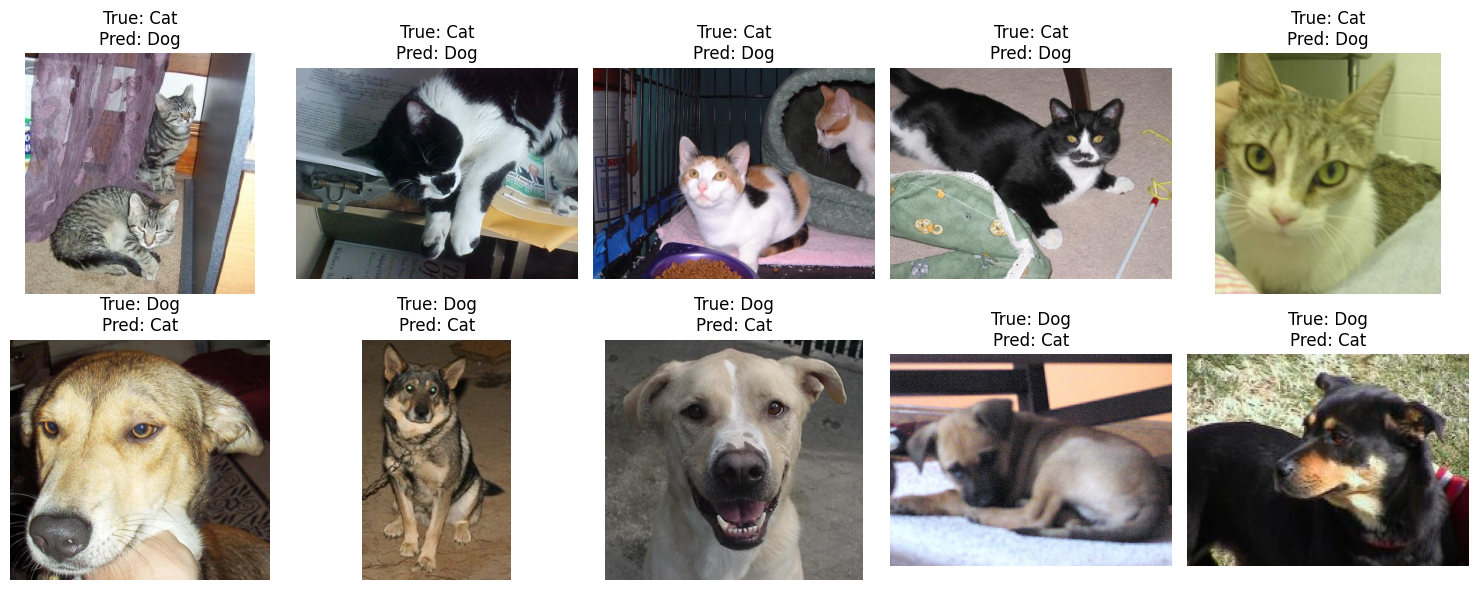

In [ ]:
class_names = ["Cat", "Dog"]

sample_fp = random.sample(false_positive_idx, min(5, len(false_positive_idx)))
sample_fn = random.sample(false_negative_idx, min(5, len(false_negative_idx)))
sample_indices = sample_fp + sample_fn

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, idx in zip(axes.flatten(), sample_indices):
    path = all_paths[idx]
    true_label = all_true_labels[idx]
    pred_label = all_predictions[idx]

    image = Image.open(path).convert("RGB")
    ax.imshow(image)
    ax.set_title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

The misclassified examples reveal several recurring patterns. Several "Cat predicted as Dog" errors involve unusual poses or contexts: two kittens photographed together on furniture, a cat mid-motion climbing on a table, and a cat photographed inside a shelter cage - all cases where the pose or background differs from a typical portrait shot. Coloring also plays a role: black-and-white patched cats appear visually similar to black-and-white patched dog breeds, which may explain some of these errors.

The "Dog predicted as Cat" errors follow a related pattern: several images are tight close-up crops of a dog's face or head, which removes the body proportions (ear shape, snout length, overall build) that are normally strong cues for distinguishing the two species. A curled-up puppy and a slender, fox-like dog photographed from a low angle also resemble typical cat poses and body shapes.

Overall, the errors are not random - they cluster around images where pose, framing, or coloring reduce the visual cues that typically separate cats from dogs, rather than reflecting a systematic bias in the model.

### 8.3 Prediction Confidence on Misclassified Images

To understand whether the model's mistakes are "close calls" or confident errors, we look at the raw sigmoid output (before thresholding at 0.5) for the misclassified test images. Predictions close to 0.5 indicate genuine uncertainty, while predictions close to 0 or 1 indicate the model was confidently wrong.

Mean distance from decision boundary (0.5): 0.1954
Median distance from decision boundary (0.5): 0.1855


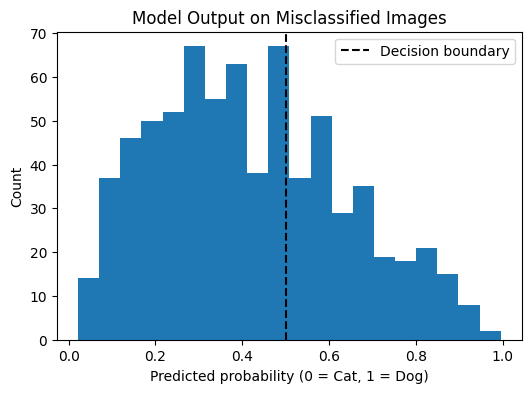

In [ ]:
model.eval()

misclassified_confidences = []

with torch.no_grad():
    for idx in misclassified_indices:
        path, true_label = test_samples[idx]
        image_tensor, _ = test_dataset[idx]
        output = model(image_tensor.unsqueeze(0).to(DEVICE))
        misclassified_confidences.append(output.item())

misclassified_confidences = np.array(misclassified_confidences)
distance_from_boundary = np.abs(misclassified_confidences - 0.5)

print(f"Mean distance from decision boundary (0.5): {distance_from_boundary.mean():.4f}")
print(f"Median distance from decision boundary (0.5): {np.median(distance_from_boundary):.4f}")

plt.figure(figsize=(6, 4))
plt.hist(misclassified_confidences, bins=20)
plt.axvline(0.5, color="black", linestyle="--", label="Decision boundary")
plt.title("Model Output on Misclassified Images")
plt.xlabel("Predicted probability (0 = Cat, 1 = Dog)")
plt.ylabel("Count")
plt.legend()
plt.show()

The mean distance from the decision boundary is 0.1954 (median 0.1855), meaning the model's misclassified predictions are, on average, only moderately far from the 0.5 threshold rather than being wildly confident in the wrong direction. The histogram confirms this: the largest concentration of errors falls in the 0.3-0.6 range, close to the decision boundary, consistent with genuinely ambiguous images where distinguishing cat from dog is difficult even visually.

At the same time, there is a noticeable right-side tail extending toward 1.0, meaning a meaningful subset of dog-predicted-as errors involved the model being quite confident (values near 0.8-1.0) despite being wrong. This asymmetry suggests the model is occasionally confidently mistaking certain images (likely images sharing strong visual cues with the opposite class, as seen in the sample grid) rather than just struggling with borderline cases. The left side (near 0.0) shows a smaller and more evenly spread set of errors, suggesting cat-predicted-as-dog mistakes are more often genuine close calls.

## References

**Dataset source:** [Microsoft "Kaggle Cats and Dogs" Dataset](https://www.microsoft.com/en-us/download/details.aspx?id=54765)